# Klimadaten MeteoSchweiz CH2025

### Zukunftszenarien mit verschiedenen Erwärmungsniveaus

## 1. Importieren Dependencies

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import packaging as pg
import netCDF4 as n4
import scipy as sc
import pydap as pp
import geopandas as gpd
import regionmask
import sys
import geodatasets
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
import dask as dk
from pathlib import Path
import rioxarray as rxr
import rasterio
from rasterio.transform import from_bounds
from rasterio.enums import Resampling
from rasterio.warp import reproject, Resampling
import fiona

Flag für Export bei Run All (sehr sehr grosse Dateien)

In [2]:
DO_EXPORT = False

## 2. Datei-Inhalte laden und überprüfen

In [3]:
# aktuelles Notebook-Verzeichnis
BASE_DIR = Path().resolve()
# zum Projekt-Root hochgehen
PROJECT_ROOT = BASE_DIR.parent

# Pfade definieren
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXPORT_DIR = PROJECT_ROOT / "exports"


In [4]:
ds_tas = xr.open_dataset(
    RAW_DIR/"ogd-climate-scenarios-ch2025-grid_ch_tas_clmcom-cclm4-ecearth_ref91-20.nc",
    chunks={"time": 365}
)

print(ds_tas)

<xarray.Dataset> Size: 4GB
Dimensions:                 (time: 10950, N: 240, E: 370)
Coordinates:
  * time                    (time) object 88kB 0001-01-01 00:00:00 ... 0030-1...
  * N                       (N) float64 2kB 1.064e+06 1.066e+06 ... 1.304e+06
  * E                       (E) float64 3kB 2.474e+06 2.476e+06 ... 2.844e+06
    lon                     (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    lat                     (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
Data variables:
    swiss_lv95_coordinates  float32 4B ...
    tas                     (time, N, E) float32 4GB dask.array<chunksize=(365, 240, 370), meta=np.ndarray>
Attributes: (12/20)
    CDI:                    Climate Data Interface version 2.4.0 (https://mpi...
    Conventions:            CF-1.8
    CDO:                    Climate Data Operators version 2.4.0 (https://mpi...
    NCO:                    netCDF Operators version 5.1.9 (Homepage = http:/...
  

In [5]:
print(ds_tas.data_vars)
print(ds_tas.coords)
print(ds_tas.dims)

Data variables:
    swiss_lv95_coordinates  float32 4B ...
    tas                     (time, N, E) float32 4GB dask.array<chunksize=(365, 240, 370), meta=np.ndarray>
Coordinates:
  * time     (time) object 88kB 0001-01-01 00:00:00 ... 0030-12-31 00:00:00
  * N        (N) float64 2kB 1.064e+06 1.066e+06 ... 1.302e+06 1.304e+06
  * E        (E) float64 3kB 2.474e+06 2.476e+06 ... 2.842e+06 2.844e+06
    lon      (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    lat      (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'time': 10950, 'N': 240, 'E': 370})


In [6]:
tas = ds_tas["tas"]
print(tas)

<xarray.DataArray 'tas' (time: 10950, N: 240, E: 370)> Size: 4GB
dask.array<open_dataset-tas, shape=(10950, 240, 370), dtype=float32, chunksize=(365, 240, 370), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 88kB 0001-01-01 00:00:00 ... 0030-12-31 00:00:00
  * N        (N) float64 2kB 1.064e+06 1.066e+06 ... 1.302e+06 1.304e+06
  * E        (E) float64 3kB 2.474e+06 2.476e+06 ... 2.842e+06 2.844e+06
    lon      (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    lat      (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
Attributes:
    units:           degrees_C
    grid_mapping:    swiss_lv95_coordinates
    esri_pe_string:  PROJCS["CH1903+_LV95",GEOGCS["GCS_CH1903+",DATUM["D_CH19...
    grid_name:       ch01r.swiss.lv95
    long_name:       Daily mean 2m temperature
    standard_name:   air_temperature
    method:          Bias-corrected and downscaled by QM


In [7]:
print("N min:", float(ds_tas["N"].min().compute()))
print("N max:", float(ds_tas["N"].max().compute()))
print("E min:", float(ds_tas["E"].min().compute()))
print("E max:", float(ds_tas["E"].max().compute()))

print("First times:", ds_tas["time"][:5].values)
print("Last times:", ds_tas["time"][-5:].values)
print("Time attrs:", ds_tas["time"].attrs)

N min: 1064500.0
N max: 1303500.0
E min: 2474500.0
E max: 2843500.0
First times: [cftime.DatetimeNoLeap(1, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1, 1, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1, 1, 3, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1, 1, 4, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1, 1, 5, 0, 0, 0, 0, has_year_zero=True)]
Last times: [cftime.DatetimeNoLeap(30, 12, 27, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(30, 12, 28, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(30, 12, 29, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(30, 12, 30, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(30, 12, 31, 0, 0, 0, 0, has_year_zero=True)]
Time attrs: {'standard_name': 'time', 'long_name': 'time', 'axis': 'T'}


In [8]:
print(ds_tas["lat"])
print(ds_tas["lon"])

<xarray.DataArray 'lat' (N: 240, E: 370)> Size: 355kB
dask.array<open_dataset-lat, shape=(240, 370), dtype=float32, chunksize=(240, 370), chunktype=numpy.ndarray>
Coordinates:
  * N        (N) float64 2kB 1.064e+06 1.066e+06 ... 1.302e+06 1.304e+06
  * E        (E) float64 3kB 2.474e+06 2.476e+06 ... 2.842e+06 2.844e+06
    lon      (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    lat      (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
Attributes:
    standard_name:        latitude
    long_name:            latitude coordinate
    units:                degrees_north
    _CoordinateAxisType:  Lat
<xarray.DataArray 'lon' (N: 240, E: 370)> Size: 355kB
dask.array<open_dataset-lon, shape=(240, 370), dtype=float32, chunksize=(240, 370), chunktype=numpy.ndarray>
Coordinates:
  * N        (N) float64 2kB 1.064e+06 1.066e+06 ... 1.302e+06 1.304e+06
  * E        (E) float64 3kB 2.474e+06 2.476e+06 ... 2.842e+06 2.844e+06
    lon      (N, E) float

In [9]:
ds_tas.time
#erstes und letztes Jahr der 30-jährigen Referenzperiode mit jeweils erstem und letztem Tag.

<xarray.DataArray 'time' (time: 10950)> Size: 88kB
array([cftime.DatetimeNoLeap(1, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(30, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(30, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(30, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      shape=(10950,), dtype=object)
Coordinates:
  * time     (time) object 88kB 0001-01-01 00:00:00 ... 0030-12-31 00:00:00
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T

In [10]:
ds_tas.time.values[:5]

array([cftime.DatetimeNoLeap(1, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1, 1, 3, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1, 1, 4, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1, 1, 5, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)

In [11]:
def load_ch2025(filename):
    path = RAW_DIR / filename

    if not path.exists():
        raise FileNotFoundError(f"Datei nicht gefunden: {path.resolve()}")

    ds = xr.open_dataset(path, chunks={"time": 365})

    # Falls vorhanden, Koordinaten umbenennen
    rename_dict = {}
    if "E" in ds.coords or "E" in ds.dims:
        rename_dict["E"] = "x"
    if "N" in ds.coords or "N" in ds.dims:
        rename_dict["N"] = "y"

    if rename_dict:
        ds = ds.rename(rename_dict)

    return ds

In [12]:
ds_tas_ref = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tas_clmcom-cclm4-ecearth_ref91-20.nc"
)
ds_tasmax_ref = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tasmax_clmcom-cclm4-ecearth_ref91-20.nc"
)

In [13]:
ds_tas_gwl1_5 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tas_clmcom-cclm4-ecearth_gwl1.5.nc"
)
ds_tasmax_gwl1_5 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tasmax_clmcom-cclm4-ecearth_gwl1.5.nc"
)

In [14]:
ds_tas_gwl2_0 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tas_clmcom-cclm4-ecearth_gwl2.0.nc"
)
ds_tasmax_gwl2_0 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tasmax_clmcom-cclm4-ecearth_gwl2.0.nc"
)

In [15]:
ds_tas_gwl2_5 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tas_clmcom-cclm4-ecearth_gwl2.5.nc"
)
ds_tasmax_gwl2_5 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tasmax_clmcom-cclm4-ecearth_gwl2.5.nc"
)

In [16]:
ds_tas_gwl3_0 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tas_clmcom-cclm4-ecearth_gwl3.0.nc"
)
ds_tasmax_gwl3_0 = load_ch2025(
    "ogd-climate-scenarios-ch2025-grid_ch_tasmax_clmcom-cclm4-ecearth_gwl3.0.nc"
)

In [17]:
print(ds_tas_ref.dims)
print(ds_tas_gwl2_5.dims)

FrozenMappingWarningOnValuesAccess({'time': 10950, 'y': 240, 'x': 370})
FrozenMappingWarningOnValuesAccess({'time': 10950, 'y': 240, 'x': 370})


In [18]:
ds_tas_all = xr.concat(
    [
        ds_tas_ref.assign_coords(scenario="ref"),
        ds_tas_gwl1_5.assign_coords(scenario="gwl1_5"),
        ds_tas_gwl2_0.assign_coords(scenario="gwl2_0"),
        ds_tas_gwl2_5.assign_coords(scenario="gwl2_5"),
        ds_tas_gwl3_0.assign_coords(scenario="gwl3_0"),
    ],
    dim="scenario"
)

ds_tas_all = ds_tas_all.sortby("scenario")

In [19]:
ds_tasmax_all = xr.concat(
    [
        ds_tasmax_ref.assign_coords(scenario="ref"),
        ds_tasmax_gwl1_5.assign_coords(scenario="gwl1_5"),
        ds_tasmax_gwl2_0.assign_coords(scenario="gwl2_0"),
        ds_tasmax_gwl2_5.assign_coords(scenario="gwl2_5"),
        ds_tasmax_gwl3_0.assign_coords(scenario="gwl3_0"),
    ],
    dim="scenario"
)

ds_tasmax_all = ds_tasmax_all.sortby("scenario")

In [20]:
# Schweiz-Grenze laden
schweiz = gpd.read_file(RAW_DIR/"swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")
print(fiona.listlayers(RAW_DIR/"swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"))

C:\Users\danie\OneDrive\FHNW DS\GitProjects\OL-FS26-klimadaten-challenge\.venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'swissBOUNDARIES3D_1_5_LV95_LN02.gpkg': 'tlm_hoheitsgrenze' (default), 'tlm_hoheitsgebiet', 'tlm_bezirksgebiet', 'tlm_landesgebiet', 'tlm_kantonsgebiet'. Specify layer parameter to avoid this warning.
  result = read_func(


['tlm_hoheitsgrenze', 'tlm_hoheitsgebiet', 'tlm_bezirksgebiet', 'tlm_landesgebiet', 'tlm_kantonsgebiet']


In [21]:
schweiz = gpd.read_file(
    RAW_DIR/"swissBOUNDARIES3D_1_5_LV95_LN02.gpkg",
    layer="tlm_landesgebiet"
)

In [22]:
schweiz = schweiz.to_crs("EPSG:2056")

## 3. Erste Auswertungen

In [23]:
heatdays = (ds_tasmax_all.tasmax >= 30) \
    .groupby("time.year") \
    .sum()

heatdays_mean = heatdays.mean(dim="year")

delta_heat = heatdays_mean.sel(scenario="gwl2_0") - heatdays_mean.sel(scenario="ref")

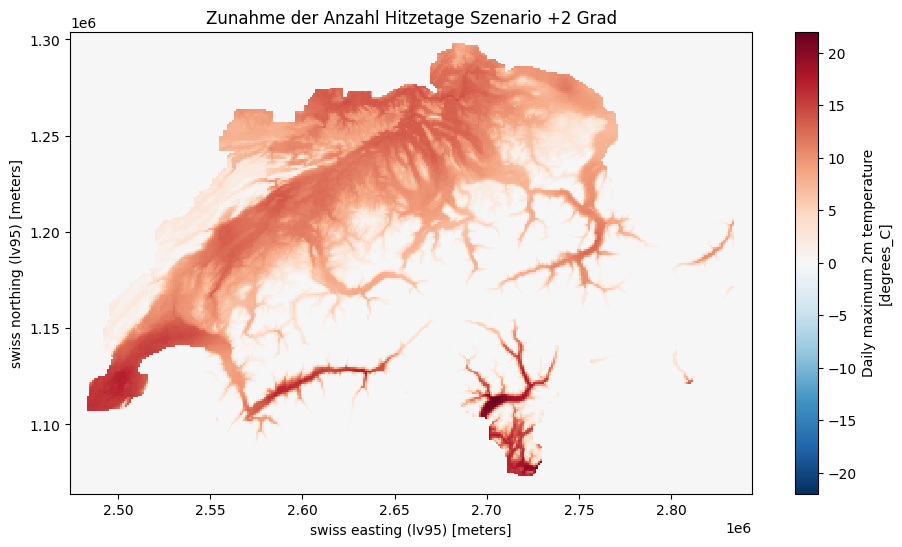

In [24]:
plt.figure(figsize=(11, 6))
delta_heat.plot()
plt.title("Zunahme der Anzahl Hitzetage Szenario +2 Grad")
plt.show()

In [25]:
gdd = (ds_tas_all.tas - 5).clip(min=0) \
    .groupby("time.year") \
    .sum()

gdd_mean = gdd.mean(dim="year")

delta_gdd = gdd_mean.sel(scenario="gwl2_0") - gdd_mean.sel(scenario="ref")

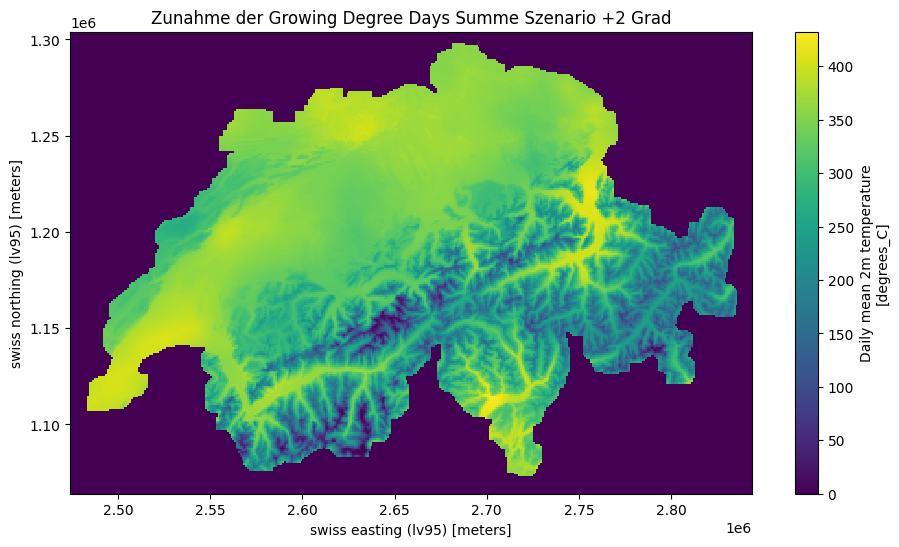

In [26]:
plt.figure(figsize=(11, 6))
delta_gdd.plot()
plt.title("Zunahme der Growing Degree Days Summe Szenario +2 Grad")
plt.show()

______________________________________________________________________

## 4. Höhenzonen

### 4.1 Höhenraster vorbereiten

In [27]:
print(ds_tas_gwl2_5)
print(ds_tas_gwl2_5.dims)
print(ds_tas_gwl2_5.coords)

<xarray.Dataset> Size: 4GB
Dimensions:                 (time: 10950, y: 240, x: 370)
Coordinates:
  * time                    (time) object 88kB 0001-01-01 00:00:00 ... 0030-1...
  * y                       (y) float64 2kB 1.064e+06 1.066e+06 ... 1.304e+06
  * x                       (x) float64 3kB 2.474e+06 2.476e+06 ... 2.844e+06
    lon                     (y, x) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    lat                     (y, x) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
Data variables:
    swiss_lv95_coordinates  float32 4B ...
    tas                     (time, y, x) float32 4GB dask.array<chunksize=(365, 240, 370), meta=np.ndarray>
Attributes: (12/20)
    CDI:                    Climate Data Interface version 2.4.0 (https://mpi...
    Conventions:            CF-1.8
    CDO:                    Climate Data Operators version 2.4.0 (https://mpi...
    NCO:                    netCDF Operators version 5.1.9 (Homepage = http:/...
  

In [28]:
dem = rxr.open_rasterio(RAW_DIR/"swissaltiregio_2056_5728.tif", masked=True).squeeze()
print(dem)
print(dem.rio.crs)
print(dem.rio.bounds())
print(dem.shape)

<xarray.DataArray (y: 43000, x: 55000)> Size: 9GB
[2365000000 values with dtype=float32]
Coordinates:
  * y            (y) float64 344kB 1.404e+06 1.404e+06 ... 9.74e+05 9.74e+05
  * x            (x) float64 440kB 2.385e+06 2.385e+06 ... 2.935e+06 2.935e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COVARIANCES:  552612.4976552565
    STATISTICS_MAXIMUM:      4799.4462890625
    STATISTICS_MEAN:         832.2516365594
    STATISTICS_MEDIAN:       546.806933
    STATISTICS_MINIMUM:      1.114272236824
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       743.37910762629
    scale_factor:            1.0
    add_offset:              0.0
EPSG:2056
(2385000.0, 974000.0, 2935000.0, 1404000.0)
(43000, 55000)


C:\Users\danie\OneDrive\FHNW DS\GitProjects\OL-FS26-klimadaten-challenge\.venv\Lib\site-packages\pyproj\crs\_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


### 4.2 Zielraster vorbereiten und mappen

In [29]:
print(ds_tas_gwl2_5.x.min().item(), ds_tas_gwl2_5.x.max().item())
print(ds_tas_gwl2_5.y.min().item(), ds_tas_gwl2_5.y.max().item())

print(dem.rio.bounds())

2474500.0 2843500.0
1064500.0 1303500.0
(2385000.0, 974000.0, 2935000.0, 1404000.0)


In [30]:
# Zielraster aus CH2025
x = ds_tas_gwl2_5.x.values
y = ds_tas_gwl2_5.y.values

nx = len(x)
ny = len(y)

dx = float(np.abs(x[1] - x[0]))
dy = float(np.abs(y[1] - y[0]))

xmin = float(x.min() - dx / 2)
xmax = float(x.max() + dx / 2)
ymin = float(y.min() - dy / 2)
ymax = float(y.max() + dy / 2)

# Ziel-Transformation
dst_transform = from_bounds(xmin, ymin, xmax, ymax, nx, ny)

# Zielarray
dst = np.empty((ny, nx), dtype=np.float32)

dem_path = "../data/raw/swissaltiregio_2056_5728.tif"

with rasterio.open(dem_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=dst,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=src.crs,   # gleiches CRS wie Quelle
        resampling=Resampling.average #nicht nearest da zu rechenintensiv
    )

elevation_on_ch = xr.DataArray(
    dst,
    coords={"y": ds_tas_gwl2_5.y, "x": ds_tas_gwl2_5.x},
    dims=("y", "x"),
    name="elevation"
)

In [31]:
elevation_on_ch = xr.DataArray(
    np.flipud(dst),
    coords={"y": ds_tas_gwl2_5.y, "x": ds_tas_gwl2_5.x},
    dims=("y", "x"),
    name="elevation"
)

In [32]:
elevation_on_ch = elevation_on_ch.rio.write_crs("EPSG:2056")

elevation_on_ch_clip = elevation_on_ch.rio.clip(
    schweiz.geometry,
    schweiz.crs,
    drop=False
)

C:\Users\danie\OneDrive\FHNW DS\GitProjects\OL-FS26-klimadaten-challenge\.venv\Lib\site-packages\pyproj\crs\_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(
C:\Users\danie\OneDrive\FHNW DS\GitProjects\OL-FS26-klimadaten-challenge\.venv\Lib\site-packages\pyproj\crs\_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


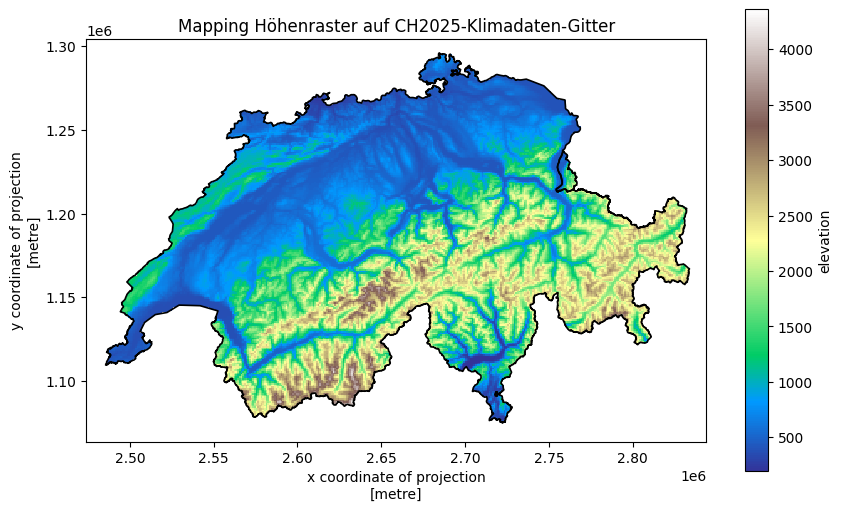

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

elevation_on_ch_clip.plot(ax=ax, cmap="terrain")
schweiz.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=10)

ax.set_title("Mapping Höhenraster auf CH2025-Klimadaten-Gitter")
plt.show()

### 4.3 Zonen zuweisen

Das Höhenraster wird auf die beiden Temperaturgitter abgebildet, um die Rasterzellen den Höhenzonen zuzuordnen.

In [34]:
zone_ch = xr.where(
    elevation_on_ch_clip < 700, 1,
    xr.where(elevation_on_ch_clip < 1500, 2, 3)
).rename("zone")

In [35]:
# Unterschiedliche Metadaten ausgleichen
zone_ch = zone_ch.reset_coords(drop=True)
zone_ch = zone_ch.assign_coords(
    x=ds_tas_all.x,
    y=ds_tas_all.y
)

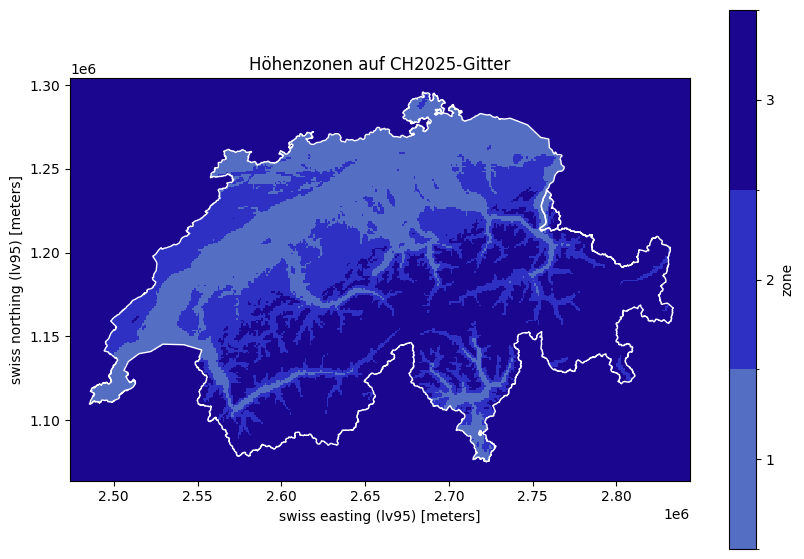

In [36]:
cmap = ListedColormap(["#546EC4", "#2E30C4", "#1B078F"])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 7))

zone_ch.plot(ax=ax, cmap=cmap, norm=norm, cbar_kwargs={"ticks": [1, 2, 3]})
schweiz.boundary.plot(ax=ax, color="white", linewidth=1.0, zorder=10)

ax.set_title("Höhenzonen auf CH2025-Gitter")
plt.show()

In [37]:
print("Mittelland:", int((zone_ch == 1).sum().item()))
print("Voralpen:", int((zone_ch == 2).sum().item()))
print("Hochgebirge:", int((zone_ch == 3).sum().item()))

Mittelland: 13634
Voralpen: 12438
Hochgebirge: 62728


In [38]:
print(zone_ch.x.equals(ds_tas_all.x))
print(zone_ch.y.equals(ds_tas_all.y))

True
True


In [39]:
ds_tas_all = ds_tas_all.assign_coords(zone=zone_ch)
ds_tasmax_all = ds_tasmax_all.assign_coords(zone=zone_ch)

In [40]:
print(np.array_equal(zone_ch.x.values, ds_tas_all.x.values))
print(np.array_equal(zone_ch.y.values, ds_tas_all.y.values))

True
True


### 4.4 Datenexport für Dashboard

In [41]:
if DO_EXPORT:
    zone_ch.to_netcdf(EXPORT_DIR/"zone_ch2025.nc")

    ds_tas_all.to_netcdf(EXPORT_DIR/"ds_tas_all.nc")
    ds_tasmax_all.to_netcdf(EXPORT_DIR/"ds_tasmax_all.nc")

## 5. Analyse der Daten

Die Daten sind auf fiktive Jahre 0 - 30 aufgeteilt, welche wiederum Monate und Tage enthalten. Es soll daher nachfolgend vorallem auf Monate aggregiert werden.

### 5.1 Monatlicher Temperaturmittelwert pro Höhenzone

In [42]:
tas_monthly = ds_tas_all.tas.groupby("time.month").mean()

tas_monthly_zone = (
    tas_monthly
    .groupby(ds_tas_all.zone)
    .mean(dim="stacked_y_x")
)

print(tas_monthly_zone)
print(tas_monthly_zone.dims)

<xarray.DataArray 'tas' (scenario: 5, month: 12, zone: 3)> Size: 720B
dask.array<transpose, shape=(5, 12, 3), dtype=float32, chunksize=(1, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * scenario  (scenario) <U6 120B 'gwl1_5' 'gwl2_0' 'gwl2_5' 'gwl3_0' 'ref'
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * zone      (zone) int64 24B 1 2 3
Attributes:
    units:           degrees_C
    grid_mapping:    swiss_lv95_coordinates
    esri_pe_string:  PROJCS["CH1903+_LV95",GEOGCS["GCS_CH1903+",DATUM["D_CH19...
    grid_name:       ch01r.swiss.lv95
    long_name:       Daily mean 2m temperature
    standard_name:   air_temperature
    method:          Bias-corrected and downscaled by QM
('scenario', 'month', 'zone')


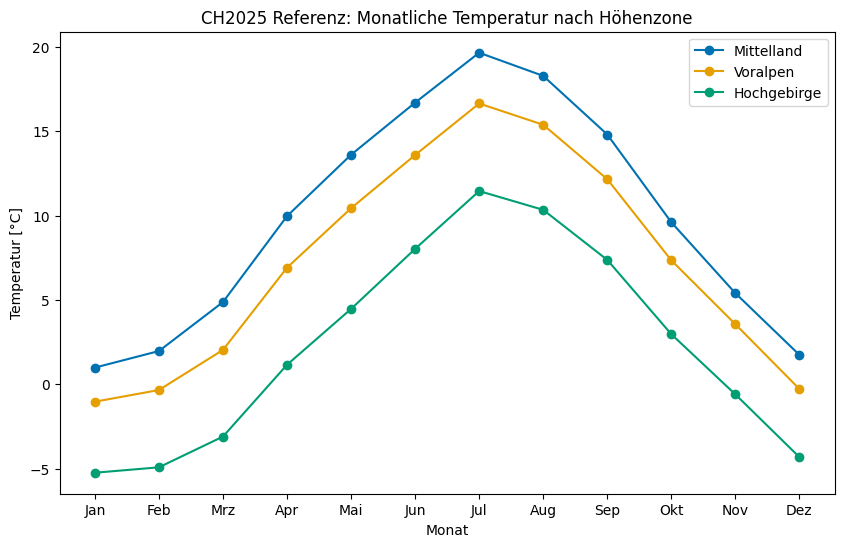

In [43]:
months = ["Jan","Feb","Mrz","Apr","Mai","Jun",
          "Jul","Aug","Sep","Okt","Nov","Dez"]

fig, ax = plt.subplots(figsize=(10, 6))

for zone, label, color in [
    (1, "Mittelland", "#0072B2"),
    (2, "Voralpen", "#E69F00"),
    (3, "Hochgebirge", "#009E73"),
]:
    vals = tas_monthly_zone.sel(scenario="ref", zone=zone)
    ax.plot(range(1, 13), vals, marker="o", color=color, label=label)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("CH2025 Referenz: Monatliche Temperatur nach Höhenzone")
ax.set_xlabel("Monat")
ax.set_ylabel("Temperatur [°C]")
ax.legend()
plt.show()

### 5.2 Monatliche Hitzetage berechnen

In [44]:
heatdays = (ds_tasmax_all.tasmax >= 30)

heatdays_monthly = heatdays.groupby("time.month").sum()

heatdays_monthly_zone = (
    heatdays_monthly
    .groupby(ds_tasmax_all.zone)
    .mean(dim="stacked_y_x")
)

print(heatdays_monthly_zone)
print(heatdays_monthly_zone.dims)

<xarray.DataArray 'tasmax' (scenario: 5, month: 12, zone: 3)> Size: 1kB
dask.array<transpose, shape=(5, 12, 3), dtype=float64, chunksize=(1, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * scenario  (scenario) <U6 120B 'gwl1_5' 'gwl2_0' 'gwl2_5' 'gwl3_0' 'ref'
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * zone      (zone) int64 24B 1 2 3
Attributes:
    units:           degrees_C
    grid_mapping:    swiss_lv95_coordinates
    esri_pe_string:  PROJCS["CH1903+_LV95",GEOGCS["GCS_CH1903+",DATUM["D_CH19...
    grid_name:       ch01r.swiss.lv95
    long_name:       Daily maximum 2m temperature
    standard_name:   air_temperature
    method:          Bias-corrected and downscaled by QM
('scenario', 'month', 'zone')


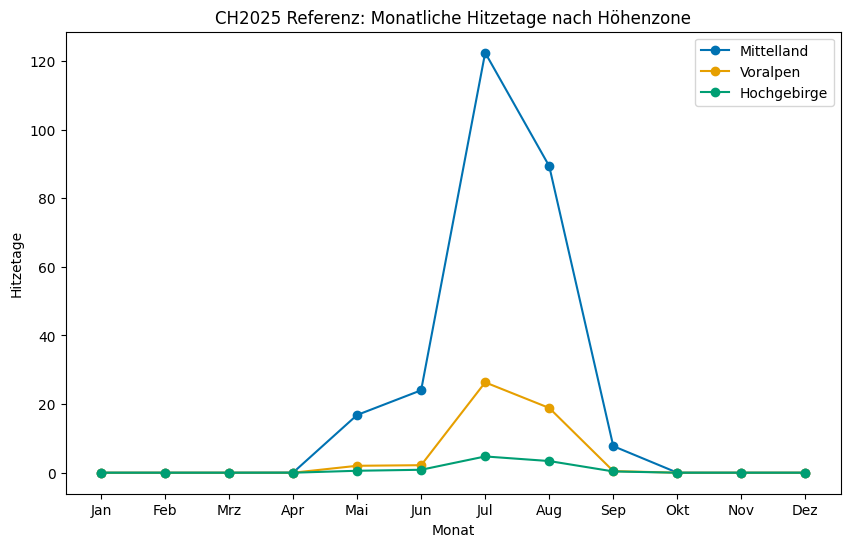

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

for zone, label, color in [
    (1, "Mittelland", "#0072B2"),
    (2, "Voralpen", "#E69F00"),
    (3, "Hochgebirge", "#009E73"),
]:
    vals = heatdays_monthly_zone.sel(scenario="ref", zone=zone)
    ax.plot(range(1, 13), vals, marker="o", color=color, label=label)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("CH2025 Referenz: Monatliche Hitzetage nach Höhenzone")
ax.set_xlabel("Monat")
ax.set_ylabel("Hitzetage")
ax.legend()
plt.show()

### 5.3 GDD pro Monat pro Höhenzone

In [46]:
gdd = (ds_tas_all.tas - 5).clip(min=0)

gdd_monthly = gdd.groupby("time.month").sum()

gdd_monthly_stacked = gdd_monthly.stack(cell=("y", "x"))
zone_stacked = ds_tas_all.zone.stack(cell=("y", "x"))

gdd_monthly_zone = gdd_monthly_stacked.groupby(zone_stacked).mean(dim="cell")

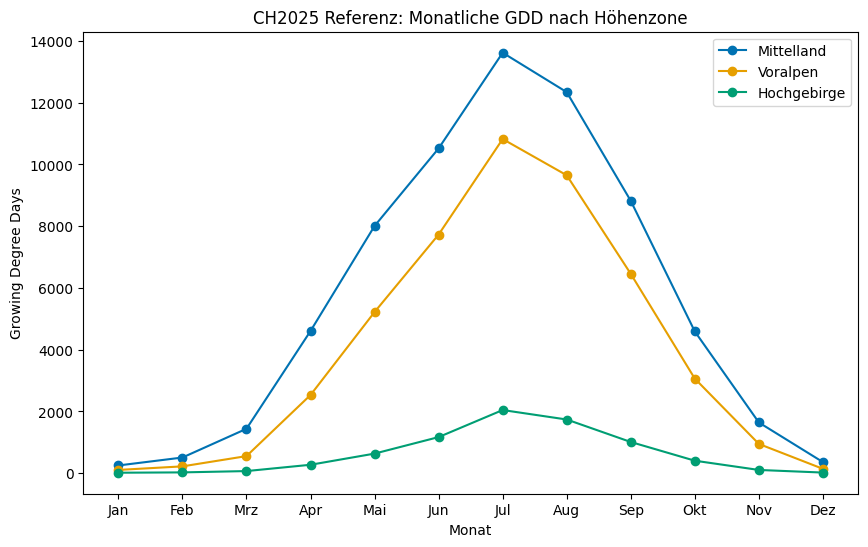

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

for zone, label, color in [
    (1, "Mittelland", "#0072B2"),
    (2, "Voralpen", "#E69F00"),
    (3, "Hochgebirge", "#009E73"),
]:
    vals = gdd_monthly_zone.sel(scenario="ref", zone=zone)
    ax.plot(range(1, 13), vals, marker="o", color=color, label=label)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("CH2025 Referenz: Monatliche GDD nach Höhenzone")
ax.set_xlabel("Monat")
ax.set_ylabel("Growing Degree Days")
ax.legend()
plt.show()

## 6. Differenzen Szenarien vs. Referenzwerte

In [48]:
print(tas_monthly_zone.scenario.values)

['gwl1_5' 'gwl2_0' 'gwl2_5' 'gwl3_0' 'ref']


In [49]:
ref_tas = tas_monthly_zone.sel(scenario="ref")
delta_tas = tas_monthly_zone - ref_tas

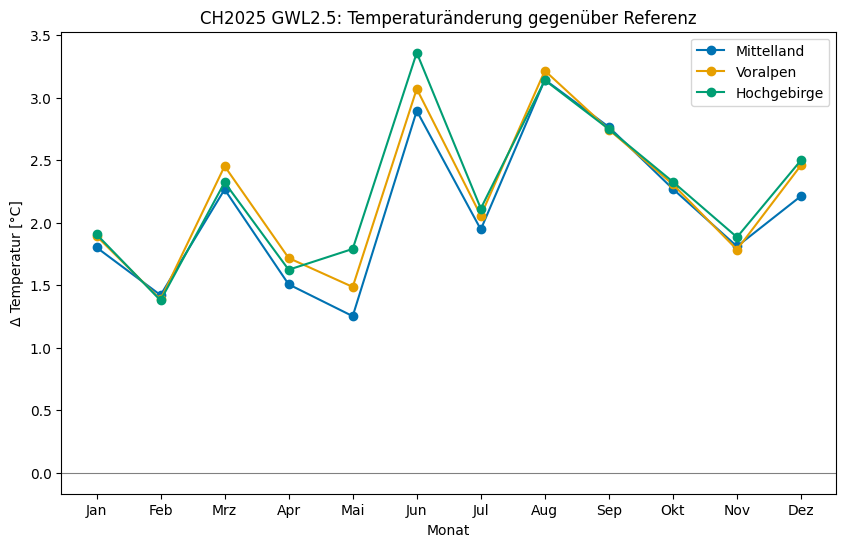

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

for zone, label, color in [
    (1, "Mittelland", "#0072B2"),
    (2, "Voralpen", "#E69F00"),
    (3, "Hochgebirge", "#009E73"),
]:
    vals = delta_tas.sel(scenario="gwl2_5", zone=zone)
    ax.plot(range(1, 13), vals, marker="o", color=color, label=label)

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("CH2025 GWL2.5: Temperaturänderung gegenüber Referenz")
ax.set_xlabel("Monat")
ax.set_ylabel("Δ Temperatur [°C]")
ax.legend()
plt.show()

In [51]:
ref_heat = heatdays_monthly_zone.sel(scenario="ref")
delta_heat = heatdays_monthly_zone - ref_heat

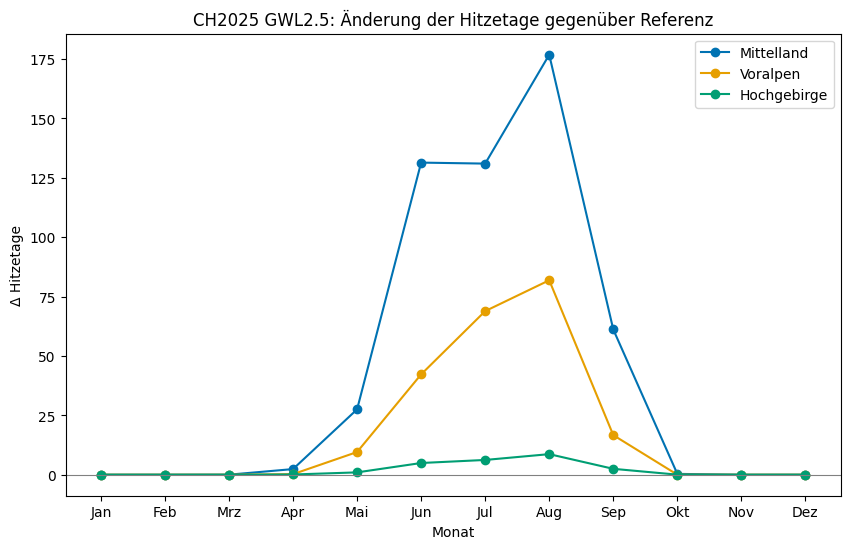

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

for zone, label, color in [
    (1, "Mittelland", "#0072B2"),
    (2, "Voralpen", "#E69F00"),
    (3, "Hochgebirge", "#009E73"),
]:
    vals = delta_heat.sel(scenario="gwl2_5", zone=zone)
    ax.plot(range(1, 13), vals, marker="o", color=color, label=label)

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("CH2025 GWL2.5: Änderung der Hitzetage gegenüber Referenz")
ax.set_xlabel("Monat")
ax.set_ylabel("Δ Hitzetage")
ax.legend()
plt.show()

In [53]:
ref_gdd = gdd_monthly_zone.sel(scenario="ref")
delta_gdd = gdd_monthly_zone - ref_gdd

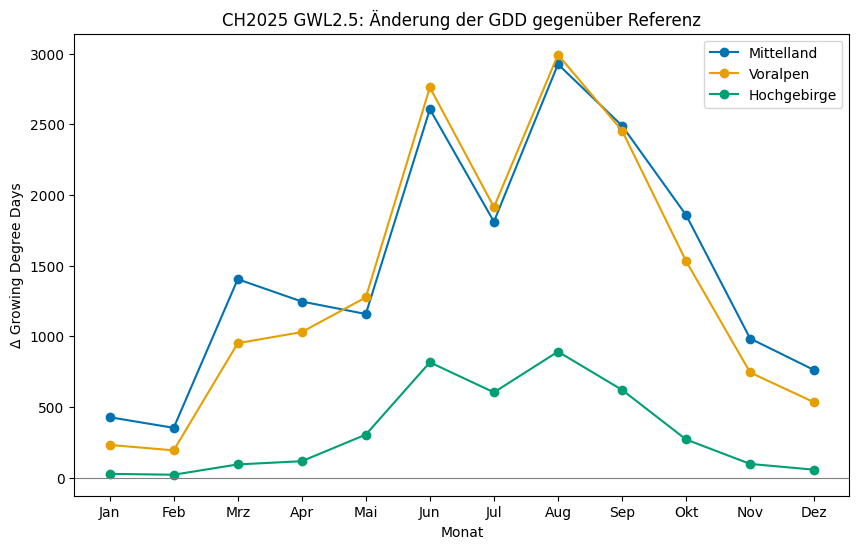

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

for zone, label, color in [
    (1, "Mittelland", "#0072B2"),
    (2, "Voralpen", "#E69F00"),
    (3, "Hochgebirge", "#009E73"),
]:
    vals = delta_gdd.sel(scenario="gwl2_5", zone=zone)
    ax.plot(range(1, 13), vals, marker="o", color=color, label=label)

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("CH2025 GWL2.5: Änderung der GDD gegenüber Referenz")
ax.set_xlabel("Monat")
ax.set_ylabel("Δ Growing Degree Days")
ax.legend()
plt.show()